<a href="https://colab.research.google.com/github/padelacruz85/DAF2026/blob/main/Milestone_1/%5BDESCRIPTIVE_ANALYSIS%5D_MotorPH_Sales_Data-3rd_Quarter-Year_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MotorPH Sales Data (3rd Quarter 2025) – Descriptive Analysis**

Converted from `[DATA_PREPROCESSING]_MotorPH_Sales_Data-3rd_Quarter-Year_2025.ipynb`: the cleaned sales data (and the cleaned product list for product attributes) is now analysed descriptively.  
Sales period in the file: **1 June – 31 August 2025**.

In [1]:
# Connecting to google drive (Colab). Skipped automatically outside Colab.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

In [2]:
# Import libraries
import os
import numpy as np                 # arithmetic and statistical computations
import pandas as pd                # data wrangling and manipulation
import matplotlib.pyplot as plt    # Basic Data Viz
import seaborn as sns              # Intermediate Statistical Data Viz
from scipy import stats            # intermediate statistical computation

sns.set_theme(style="whitegrid")
pd.options.display.float_format = "{:,.2f}".format

In [3]:
# Load Data Sets
DRIVE_DIR = "/content/drive/MyDrive/4thYR_Term1/MO-IT106 - Data Analytics Fundamentals/Week 05/Dataset Preprocessing/"
GITHUB    = "https://raw.githubusercontent.com/padelacruz85/DAF2026/main/Milestone_1/"
SALES_FILE = "[CLEANED_DATA]_MotorPH_Sales_Data-3rd_Quarter-Year_2025.csv"
PROD_FILE  = "[CLEANED_DATA]_MotorPH_Products_List_2025.csv"

def locate(fname):
    # Google Drive first, then local folders, then the GitHub repo.
    for p in [DRIVE_DIR + fname, fname, "Milestone_1/" + fname, "../Milestone_1/" + fname]:
        if os.path.exists(p):
            return p
    return GITHUB + fname.replace("[", "%5B").replace("]", "%5D")

sales_path, prod_path = locate(SALES_FILE), locate(PROD_FILE)
df_sales = pd.read_csv(sales_path, parse_dates=["Date"])
df_prod  = pd.read_csv(prod_path)
print("Sales loaded from  :", sales_path)
print("Products loaded from:", prod_path)

Sales loaded from  : [CLEANED_DATA]_MotorPH_Sales_Data-3rd_Quarter-Year_2025.csv
Products loaded from: Milestone_1/[CLEANED_DATA]_MotorPH_Products_List_2025.csv


In [4]:
# Column shortcuts
TOTAL, QTY, PRICE = "Total Sales (PHP)", "Quantity", "Unit Price (PHP)"

# Join product attributes (type, engine, cooling, transmission, displacement) using Product ID Number
df = df_sales.merge(
    df_prod[["Product ID Number", "Product Type", "Engine Type", "Cooling System", "Engine Displacement (cc)", "Transmission"]],
    on="Product ID Number", how="left", validate="m:1")

# Derived fields
multi_word = ["Moto Guzzi", "Moto Morini", "Royal Enfield", "Harley-Davidson"]       # brands made of more than one word
df["Brand"]   = df["Product Name"].apply(lambda n: next((b for b in multi_word if n.startswith(b)), n.split()[0]))
df["Month"]   = df["Date"].dt.month_name()
df["Weekday"] = df["Date"].dt.day_name()
MONTHS   = ["June", "July", "August"]
WEEKDAYS = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df.head(10)

,Transaction ID,Date,Client Type,Product ID Number,Product Name,Unit Price (PHP),Quantity,Total Sales (PHP),Payment Method,Product Type,Engine Type,Cooling System,Engine Displacement (cc),Transmission,Brand,Month,Weekday
0,1,2025-06-01,Wholesale,43,KTM 790 Duke,"599,000.00",9,"5,391,000.00",Transfer,Naked Bike,Parallel Twin,Liquid-Cooled,799,6-Speed,KTM,June,Sunday
1,2,2025-06-01,Retail,27,Yamaha Sniper 155,"125,900.00",8,"1,007,200.00",Cash,Underbone,Single Cylinder,Liquid-Cooled,155,6-Speed,Yamaha,June,Sunday
2,3,2025-06-01,Retail,29,Honda CRF300L,"284,900.00",32,"9,116,800.00",Transfer,Dual-Sport,Single Cylinder,Liquid-Cooled,286,6-Speed,Honda,June,Sunday
3,4,2025-06-01,Unknown,32,Harley-Davidson Street 750,"499,000.00",7,"3,493,000.00",Cash,Cruiser,V-Twin,Liquid-Cooled,749,6-Speed,Harley-Davidson,June,Sunday
4,5,2025-06-01,Retail,43,KTM 790 Duke,"599,000.00",1,"599,000.00",Credit Card,Naked Bike,Parallel Twin,Liquid-Cooled,799,6-Speed,KTM,June,Sunday
5,6,2025-06-01,Wholesale,23,Keeway RKS 150 Sport,"68,900.00",12,"826,800.00",Transfer,Standard,Single Cylinder,Air-Cooled,149,5-Speed,Keeway,June,Sunday
6,7,2025-06-01,Retail,35,Yamaha XMAX 300,"319,000.00",26,"8,294,000.00",Transfer,Scooter,Single Cylinder,Liquid-Cooled,292,CVT,Yamaha,June,Sunday
7,8,2025-06-01,Retail,19,Suzuki GSX-S150,"125,000.00",13,"1,625,000.00",Cash,Naked Bike,Single Cylinder,Liquid-Cooled,147,6-Speed,Suzuki,June,Sunday
8,9,2025-06-01,Retail,21,Yamaha Aerox 155,"124,000.00",38,"4,712,000.00",Cash,Scooter,Single Cylinder,Liquid-Cooled,155,CVT,Yamaha,June,Sunday
9,10,2025-06-01,Retail,28,Bajaj CT125,"67,900.00",6,"407,400.00",Credit Card,Commuter,Single Cylinder,Air-Cooled,125,4-Speed,Bajaj,June,Sunday


# **1. DATA SET OVERVIEW**

In [5]:
print("Rows, columns:", df_sales.shape)
df_sales.info()

Rows, columns: (993, 9)
<class 'pandas.DataFrame'>
RangeIndex: 993 entries, 0 to 992
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Transaction ID     993 non-null    int64         
 1   Date               993 non-null    datetime64[us]
 2   Client Type        993 non-null    str           
 3   Product ID Number  993 non-null    int64         
 4   Product Name       993 non-null    str           
 5   Unit Price (PHP)   993 non-null    float64       
 6   Quantity           993 non-null    int64         
 7   Total Sales (PHP)  993 non-null    float64       
 8   Payment Method     993 non-null    str           
dtypes: datetime64[us](1), float64(2), int64(3), str(3)
memory usage: 69.9 KB


In [6]:
print("Missing values in the sales data   :", df_sales.isna().sum().sum())
print("Duplicate rows (excl. Transaction ID):", df_sales.drop(columns="Transaction ID").duplicated().sum())
print("Rows without a matching product       :", df["Product Type"].isna().sum())
print("Period covered                        :", df["Date"].min().date(), "to", df["Date"].max().date(),
      f"({df['Date'].nunique()} days with sales)")
print("Distinct products / brands            :", df["Product Name"].nunique(), "/", df["Brand"].nunique())

Missing values in the sales data   : 0
Duplicate rows (excl. Transaction ID): 0
Rows without a matching product       : 0
Period covered                        : 2025-06-01 to 2025-08-31 (92 days with sales)
Distinct products / brands            : 50 / 24


# **2. HEADLINE FIGURES**

In [7]:
daily = df.groupby("Date")[TOTAL].sum()
kpi = pd.Series({
    "Transactions":                       len(df),
    "Total sales (PHP)":                  df[TOTAL].sum(),
    "Units sold":                         df[QTY].sum(),
    "Average sale per transaction (PHP)": df[TOTAL].mean(),
    "Median sale per transaction (PHP)":  df[TOTAL].median(),
    "Average units per transaction":      df[QTY].mean(),
    "Average daily sales (PHP)":          daily.mean(),
}, name="Value")
kpi.to_frame()

,Value
Transactions,993.00
Total sales (PHP),"4,458,070,900.00"
Units sold,"17,598.00"
Average sale per transaction (PHP),"4,489,497.38"
Median sale per transaction (PHP),"2,803,300.00"
Average units per transaction,17.72
Average daily sales (PHP),"48,457,292.39"


### Interpretation – headline figures
- MotorPH recorded **993 transactions** worth **₱4,458,070,900 (about ₱4.46 billion)** and **17,598 units** over the 92-day period.
- The average sale is **₱4,489,497**, but the median is only **₱2,803,300**, a sign that a minority of very large sales pulls the average up (see Section 3).
- Sales happened every day of the period, averaging about **₱48.5 million per day** and **17.7 units per transaction**.

# **3. NUMERICAL VARIABLES**

In [8]:
num_cols = [PRICE, QTY, TOTAL]
desc = df[num_cols].describe().T
desc["median"]   = df[num_cols].median()
desc["IQR"]      = desc["75%"] - desc["25%"]
desc["CV (%)"]   = desc["std"] / desc["mean"] * 100
desc["skewness"] = df[num_cols].skew()
desc["kurtosis"] = df[num_cols].kurt()
print("Mode of Quantity:", df[QTY].mode().tolist())
desc[["count", "mean", "median", "std", "min", "25%", "75%", "max", "IQR", "CV (%)", "skewness", "kurtosis"]]

Mode of Quantity: [5]


,count,mean,median,std,min,25%,75%,max,IQR,CV (%),skewness,kurtosis
Unit Price (PHP),993.00,"256,826.99","199,900.00","179,079.84","48,000.00","125,000.00","331,000.00","995,000.00","206,000.00",69.73,1.71,3.71
Quantity,993.00,17.72,14.00,13.31,1.00,7.00,25.00,50.00,18.00,75.09,0.86,-0.25
Total Sales (PHP),993.00,"4,489,497.38","2,803,300.00","4,966,020.75","67,900.00","1,280,000.00","6,063,000.00","32,835,000.00","4,783,000.00",110.61,2.35,7.08


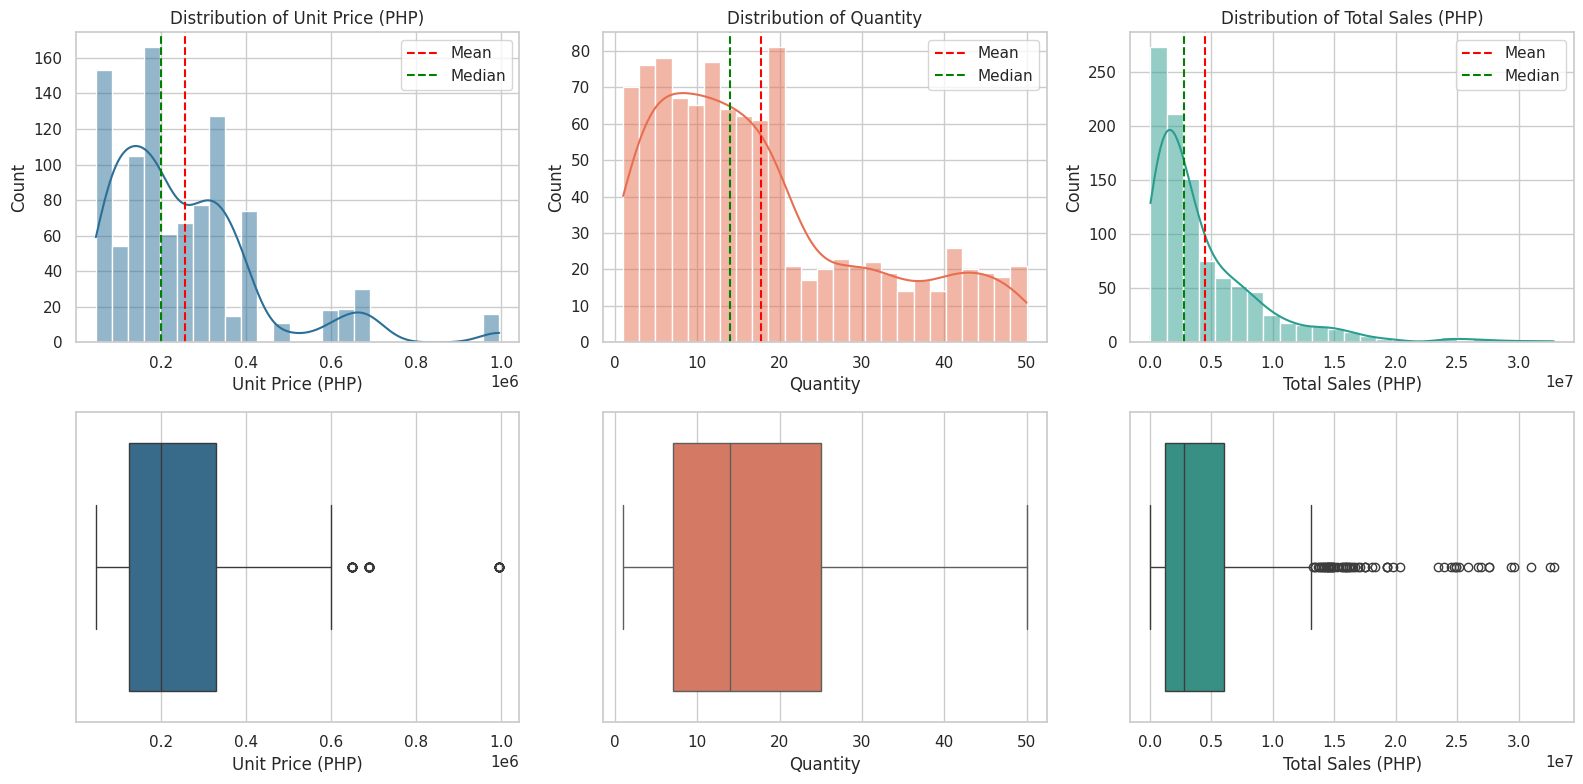

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for col, ax_h, ax_b, colr in zip(num_cols, axes[0], axes[1], ["#2a6f97", "#e76f51", "#2a9d8f"]):
    sns.histplot(df[col], bins=25, kde=True, ax=ax_h, color=colr)
    ax_h.axvline(df[col].mean(), color="red", ls="--", label="Mean")
    ax_h.axvline(df[col].median(), color="green", ls="--", label="Median")
    ax_h.set_title(f"Distribution of {col}"); ax_h.legend()
    sns.boxplot(x=df[col], ax=ax_b, color=colr)
plt.tight_layout(); plt.show()

In [10]:
# Quantity per transaction, in bands
bands = pd.cut(df[QTY], [0, 10, 20, 30, 40, 50], labels=["1-10", "11-20", "21-30", "31-40", "41-50"])
bt = bands.value_counts().sort_index().to_frame("Transactions")
bt["Percent (%)"] = (bt["Transactions"] / len(df) * 100).round(1)
bt

,Transactions,Percent (%)
Quantity,,
1-10,356,35.90
11-20,345,34.70
21-30,102,10.30
31-40,86,8.70
41-50,104,10.50


### Interpretation – numerical variables
- **Unit price** averages ₱256,827 (median ₱199,900) and ranges from ₱48,000 to ₱995,000, mirroring the product catalogue.
- **Quantity per transaction** ranges from 1 to 50 units (mean 17.7, median 14, most common value 5) with mild right skew (0.86). About **70.6%** of transactions involve 20 units or fewer.
- **Total sales per transaction** is strongly right-skewed (skewness **2.35**, coefficient of variation **111%**): the median is ₱2.80 million against a mean of ₱4.49 million, and the largest sale is **₱32,835,000** (33 units of the BMW R nineT on 30 July). The smallest is ₱67,900 (a single Bajaj CT125).

# **4. CLIENT TYPE AND PAYMENT METHOD**

In [11]:
def cat_summary(col):
    g = df.groupby(col).agg(Transactions=(TOTAL, "size"), Units=(QTY, "sum"), Sales=(TOTAL, "sum"),
                            Avg_Sale=(TOTAL, "mean"), Avg_Units=(QTY, "mean"), Median_Units=(QTY, "median"))
    g["Txn %"]   = g["Transactions"] / g["Transactions"].sum() * 100
    g["Sales %"] = g["Sales"] / g["Sales"].sum() * 100
    return g.sort_values("Sales", ascending=False)

for col in ["Client Type", "Payment Method"]:
    print(f"--- {col} ---")
    print(cat_summary(col).round(1).to_string(), "\n")

--- Client Type ---
             Transactions  Units            Sales     Avg_Sale  Avg_Units  Median_Units  Txn %  Sales %
Client Type                                                                                            
Retail                517   9307 2,386,519,400.00 4,616,091.70      18.00         15.00  52.10    53.50
Wholesale             466   8169 2,036,324,900.00 4,369,795.90      17.50         14.00  46.90    45.70
Unknown                10    122    35,226,600.00 3,522,660.00      12.20         13.00   1.00     0.80 

--- Payment Method ---
                Transactions  Units            Sales     Avg_Sale  Avg_Units  Median_Units  Txn %  Sales %
Payment Method                                                                                            
Credit Card              350   6338 1,569,820,600.00 4,485,201.70      18.10         15.00  35.20    35.20
Transfer                 327   5583 1,431,534,300.00 4,377,780.70      17.10         15.00  32.90    32.10
Cash   

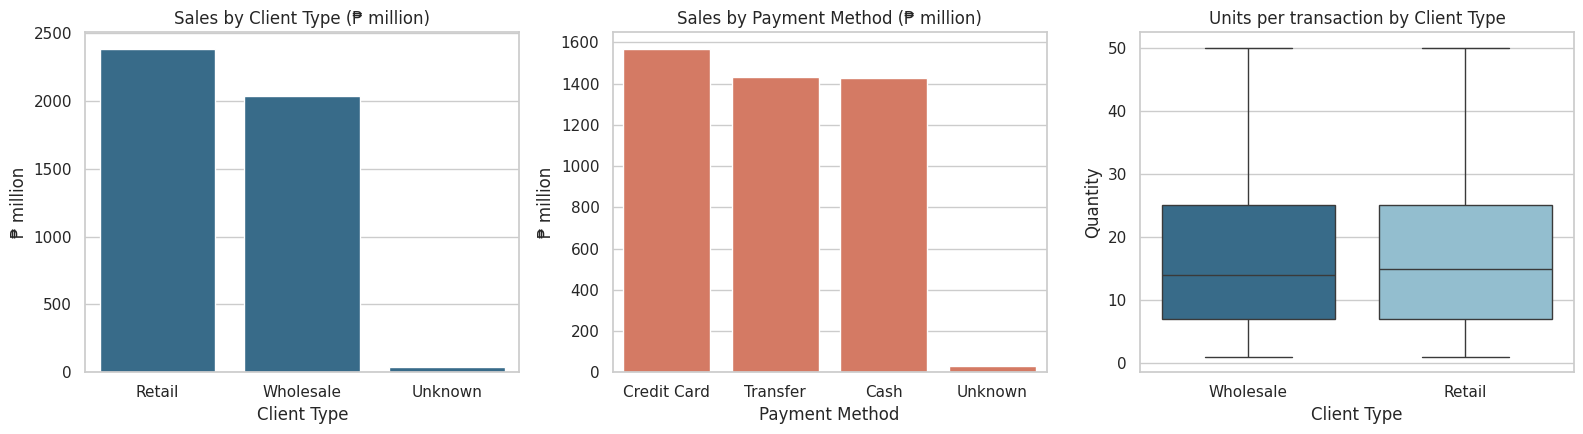

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
order_c = ["Retail", "Wholesale", "Unknown"]
sns.barplot(data=df.groupby("Client Type")[TOTAL].sum().div(1e6).reset_index(), x="Client Type", y=TOTAL, order=order_c, ax=axes[0], color="#2a6f97")
axes[0].set_title("Sales by Client Type (₱ million)"); axes[0].set_ylabel("₱ million")
order_p = ["Credit Card", "Transfer", "Cash", "Unknown"]
sns.barplot(data=df.groupby("Payment Method")[TOTAL].sum().div(1e6).reset_index(), x="Payment Method", y=TOTAL, order=order_p, ax=axes[1], color="#e76f51")
axes[1].set_title("Sales by Payment Method (₱ million)"); axes[1].set_ylabel("₱ million")
sns.boxplot(data=df[df["Client Type"] != "Unknown"], x="Client Type", y=QTY, ax=axes[2], palette=["#2a6f97", "#89c2d9"], hue="Client Type", legend=False)
axes[2].set_title("Units per transaction by Client Type")
plt.tight_layout(); plt.show()

Payment Method  Cash  Credit Card  Transfer  Unknown  All
Client Type                                              
Retail           160          186       169        2  517
Unknown            4            4         2        0   10
Wholesale        142          160       156        8  466
All              306          350       327       10  993


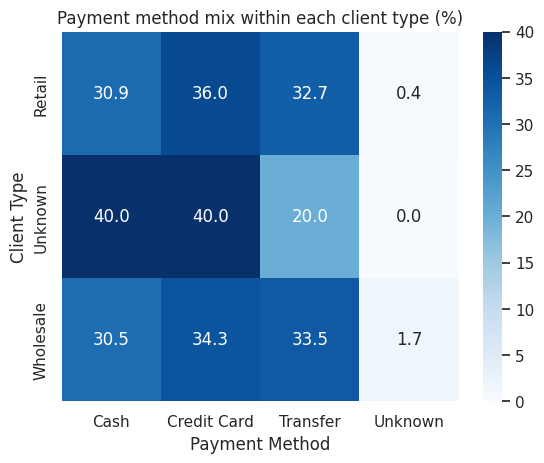

In [13]:
# Client type x payment method (transactions)
ct = pd.crosstab(df["Client Type"], df["Payment Method"], margins=True)
display(ct) if "display" in globals() else print(ct)
sns.heatmap(pd.crosstab(df["Client Type"], df["Payment Method"], normalize="index") * 100, annot=True, fmt=".1f", cmap="Blues")
plt.title("Payment method mix within each client type (%)"); plt.show()

### Interpretation – client type and payment method
- **Retail** accounts for 517 transactions (52.1%) and **53.5% of sales**; **Wholesale** has 466 transactions (46.9%) and **45.7% of sales**. Average sale values are close (₱4.62 million retail vs ₱4.37 million wholesale).
- Surprisingly, **units per transaction barely differ** between the two (mean 18.0 retail vs 17.5 wholesale; median 15 vs 14), so wholesale buyers are not purchasing noticeably larger lots in this data.
- **Credit card** is the most used method (350 transactions, 35.2% of sales), followed by **bank transfer** (327; 32.1%) and **cash** (306; 32.0%). Cash transactions have the highest average value (about ₱4.66 million).
- Payment preference is similar for both client types. About 1% of records have an unknown client type or payment method (blanks in the raw data).

# **5. SALES OVER TIME**

In [14]:
monthly = df.groupby("Month").agg(Transactions=(TOTAL, "size"), Units=(QTY, "sum"), Sales=(TOTAL, "sum"), Avg_Sale=(TOTAL, "mean")).reindex(MONTHS)
monthly["Sales (₱M)"] = monthly["Sales"] / 1e6
monthly["Change vs prior month (%)"] = monthly["Sales"].pct_change() * 100
print(monthly.round(1).to_string(), "\n")

print("Sales by month and client type (₱M):")
print((df.pivot_table(index="Month", columns="Client Type", values=TOTAL, aggfunc="sum").reindex(MONTHS) / 1e6).round(1).to_string())

        Transactions  Units            Sales     Avg_Sale  Sales (₱M)  Change vs prior month (%)
Month                                                                                           
June             342   6095 1,522,120,700.00 4,450,645.30    1,522.10                        NaN
July             331   5845 1,490,582,700.00 4,503,271.00    1,490.60                      -2.10
August           320   5658 1,445,367,500.00 4,516,773.40    1,445.40                      -3.00 

Sales by month and client type (₱M):
Client Type  Retail  Unknown  Wholesale
Month                                  
June         899.40     6.20     616.60
July         699.00     2.20     789.40
August       788.20    26.90     630.30


In [15]:
# Weekday pattern: average daily sales (calendar days with no sales would count as 0)
cal = pd.date_range(df["Date"].min(), df["Date"].max())
daily_full = daily.reindex(cal, fill_value=0)
wk = daily_full.groupby(daily_full.index.day_name()).agg(["mean", "count"]).reindex(WEEKDAYS)
wk.columns = ["Avg daily sales (PHP)", "Days in period"]
print(wk.round(0).to_string())
print("\nBest day :", daily.idxmax().date(), f"₱{daily.max():,.0f}")
print("Weakest  :", daily.idxmin().date(), f"₱{daily.min():,.0f}")
print(f"Daily sales  mean ₱{daily.mean():,.0f} | median ₱{daily.median():,.0f} | std ₱{daily.std():,.0f}")

           Avg daily sales (PHP)  Days in period
Monday             57,758,915.00              13
Tuesday            50,018,769.00              13
Wednesday          38,590,946.00              13
Thursday           58,770,400.00              13
Friday             46,636,492.00              13
Saturday           40,787,538.00              13
Sunday             46,767,936.00              14

Best day : 2025-06-14 ₱100,220,500
Weakest  : 2025-07-16 ₱13,600,200
Daily sales  mean ₱48,457,292 | median ₱44,244,500 | std ₱21,285,669


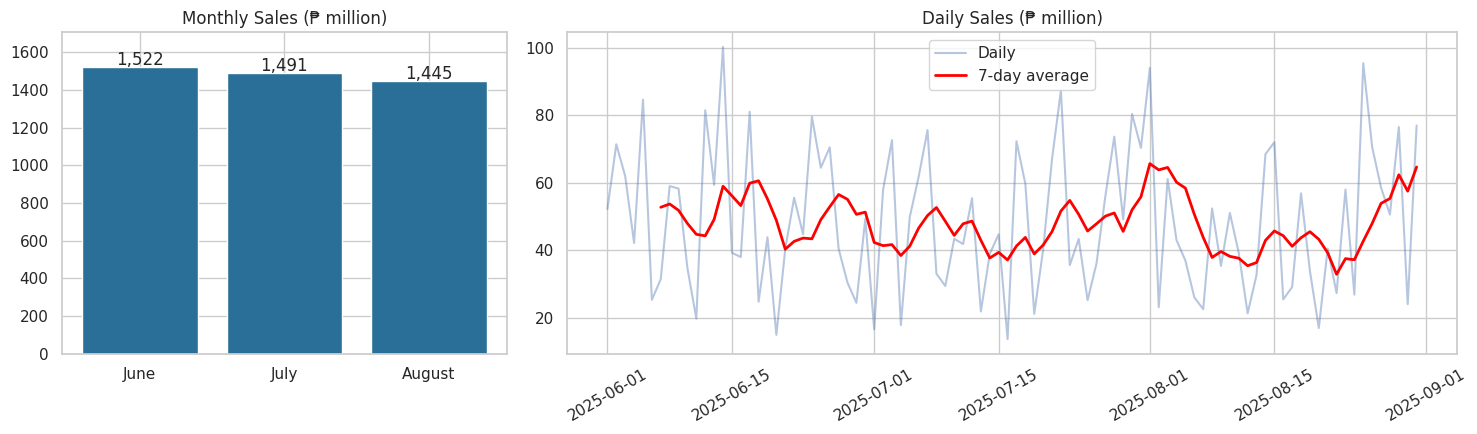

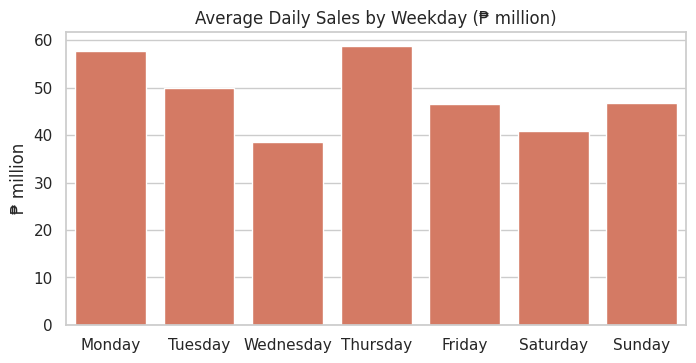

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), gridspec_kw={"width_ratios": [1, 2]})
axes[0].bar(MONTHS, monthly["Sales (₱M)"], color="#2a6f97")
for i, v in enumerate(monthly["Sales (₱M)"]): axes[0].text(i, v + 10, f"{v:,.0f}", ha="center")
axes[0].set_title("Monthly Sales (₱ million)"); axes[0].set_ylim(0, monthly["Sales (₱M)"].max() * 1.12)

axes[1].plot(daily.index, daily / 1e6, alpha=.4, label="Daily")
axes[1].plot(daily.index, daily.rolling(7).mean() / 1e6, color="red", lw=2, label="7-day average")
axes[1].set_title("Daily Sales (₱ million)"); axes[1].legend(); axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

plt.figure(figsize=(8, 3.8))
sns.barplot(x=wk.index, y=wk["Avg daily sales (PHP)"] / 1e6, color="#e76f51")
plt.title("Average Daily Sales by Weekday (₱ million)"); plt.ylabel("₱ million"); plt.xlabel(""); plt.show()

### Interpretation – sales over time
- Sales **declined steadily** across the period: **June ₱1.522 billion → July ₱1.491 billion → August ₱1.445 billion** (about **−5.0%** overall). Transactions fell from 342 to 320, while the average sale stayed roughly flat (₱4.45 million → ₱4.52 million), so the drop comes from fewer transactions rather than smaller ones.
- By client type, **retail led in June and August**, while **wholesale led only in July** (₱789 million vs ₱699 million).
- **Thursday** (₱58.8 million per day) and **Monday** (₱57.8 million) are the strongest weekdays; **Wednesday** (₱38.6 million) and **Saturday** (₱40.8 million) are the weakest.
- Daily sales are volatile (standard deviation ≈ ₱21.3 million): the best day was **14 June (₱100.2 million)** and the weakest **16 July (₱13.6 million)**.

# **6. PRODUCT PERFORMANCE**

In [17]:
prod = df.groupby("Product Name").agg(Transactions=(TOTAL, "size"), Units=(QTY, "sum"), Sales=(TOTAL, "sum"), Unit_Price=(PRICE, "first"))
prod["Sales %"] = prod["Sales"] / prod["Sales"].sum() * 100
prod = prod.sort_values("Sales", ascending=False)
prod["Cumulative %"] = prod["Sales %"].cumsum()
print("Products with sales:", len(prod), "| transactions per product: mean", round(prod["Transactions"].mean(), 1),
      "min", prod["Transactions"].min(), "max", prod["Transactions"].max())
print("\nTop 10 by sales:");   print(prod.head(10).round(1).to_string())
print("\nBottom 5 by sales:"); print(prod.tail(5).round(1).to_string())
print("\nTop 5 by units sold:"); print(prod.sort_values("Units", ascending=False).head(5)[["Units", "Sales", "Unit_Price"]].round(0).to_string())

Products with sales: 50 | transactions per product: mean 19.9 min 11 max 30

Top 10 by sales:
                     Transactions  Units          Sales  Unit_Price  Sales %  Cumulative %
Product Name                                                                              
Moto Guzzi V7 Stone            30    475 327,275,000.00  689,000.00     7.30          7.30
Bristol Bobber 650             30    575 228,850,000.00  398,000.00     5.10         12.50
BMW R nineT                    16    227 225,865,000.00  995,000.00     5.10         17.50
KTM 790 Duke                   18    363 217,437,000.00  599,000.00     4.90         22.40
Honda Rebel 1100               19    256 166,400,000.00  650,000.00     3.70         26.20
Yamaha Serow 250               26    496 148,304,000.00  299,000.00     3.30         29.50
CFMoto 650MT                   22    427 147,315,000.00  345,000.00     3.30         32.80
Vespa GTS Super 300            21    363 144,474,000.00  398,000.00     3.20         36

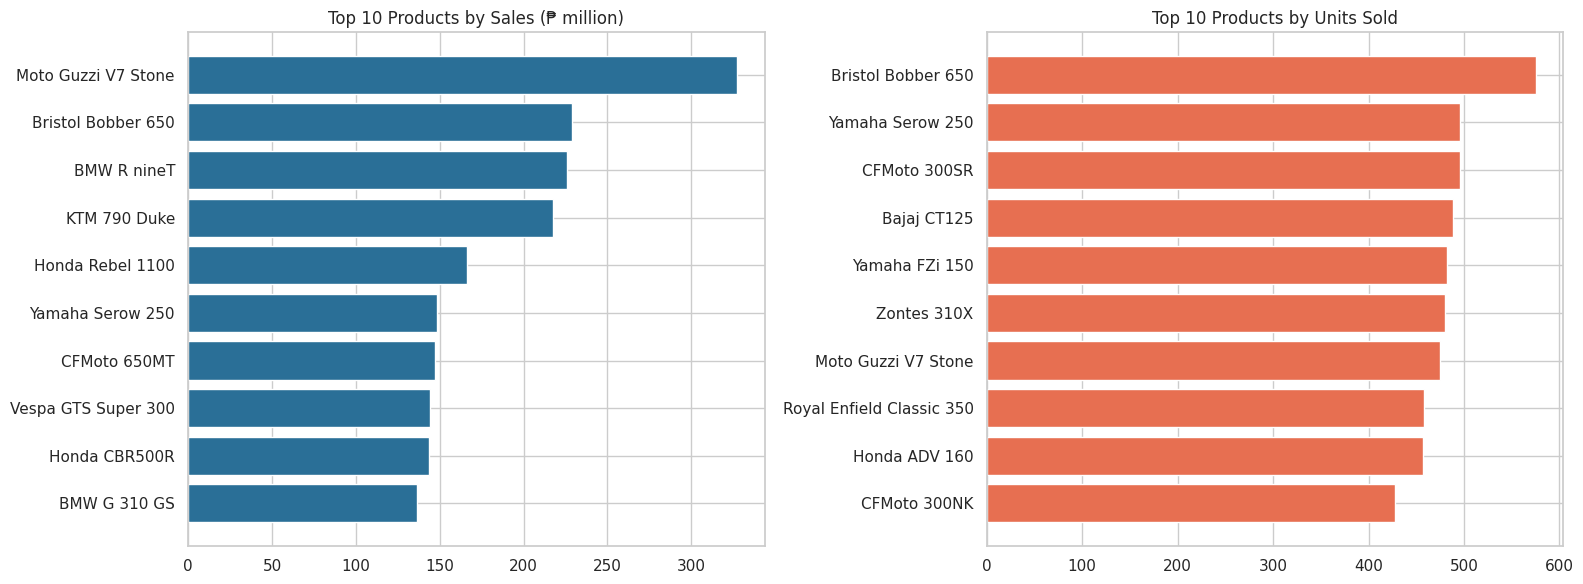

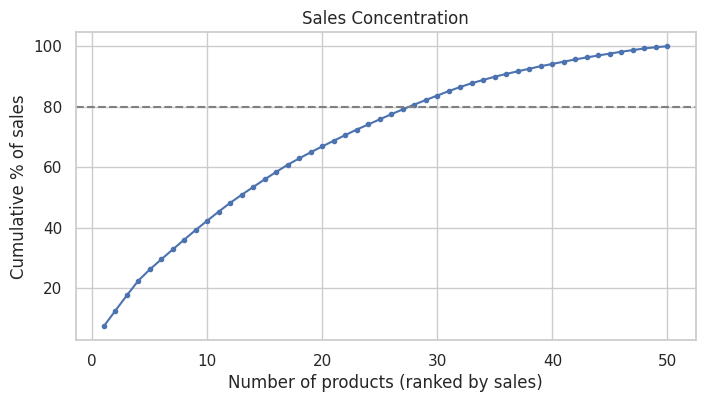

Products needed to reach 80% of sales: 28 of 50


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
t10 = prod.head(10).iloc[::-1]
axes[0].barh(t10.index, t10["Sales"] / 1e6, color="#2a6f97"); axes[0].set_title("Top 10 Products by Sales (₱ million)")
u10 = prod.sort_values("Units", ascending=False).head(10).iloc[::-1]
axes[1].barh(u10.index, u10["Units"], color="#e76f51"); axes[1].set_title("Top 10 Products by Units Sold")
plt.tight_layout(); plt.show()

# Concentration (Pareto) curve
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(prod) + 1), prod["Cumulative %"], marker="o", ms=3)
plt.axhline(80, color="gray", ls="--"); plt.xlabel("Number of products (ranked by sales)"); plt.ylabel("Cumulative % of sales")
plt.title("Sales Concentration"); plt.show()
print("Products needed to reach 80% of sales:", int((prod["Cumulative %"] < 80).sum() + 1), "of", len(prod))

### Interpretation – product performance
- All **50 products sold**, each in 11–30 transactions (about 20 on average), so sales are spread across the whole catalogue rather than a few items.
- By revenue the leaders are **Moto Guzzi V7 Stone (₱327.3 million, 7.3%)**, **Bristol Bobber 650 (₱228.9 million, 5.1%)**, **BMW R nineT (₱225.9 million, 5.1%)**, **KTM 790 Duke (₱217.4 million, 4.9%)** and **Honda Rebel 1100 (₱166.4 million, 3.7%)** – all high-priced models. The **top 10 products generate 42.3%** of sales.
- By units, **Bristol Bobber 650 (575)** is first, followed by **CFMoto 300SR and Yamaha Serow 250 (496 each)**.
- The lowest sellers by revenue are **SYM Husky 150 (₱13.9 million, 0.3%)**, **Rusi Flash 125 (₱18.9 million)** and **Honda Click 125i (₱23.7 million)**. Rusi Flash 125 still sold 393 units: low-priced models move in volume but add little revenue.

# **7. SALES BY PRODUCT ATTRIBUTES**

In [19]:
def attr_summary(col):
    g = df.groupby(col).agg(Transactions=(TOTAL, "size"), Units=(QTY, "sum"), Sales=(TOTAL, "sum"), Models=("Product ID Number", "nunique"))
    g["Txn %"]   = g["Transactions"] / g["Transactions"].sum() * 100
    g["Sales %"] = g["Sales"] / g["Sales"].sum() * 100
    g["Sales per model (₱M)"] = g["Sales"] / g["Models"] / 1e6
    return g.sort_values("Sales", ascending=False)

for col in ["Product Type", "Engine Type", "Cooling System", "Transmission"]:
    print(f"--- {col} ---"); print(attr_summary(col).round(1).to_string(), "\n")
print("--- Brand (top 8) ---"); print(attr_summary("Brand").head(8).round(1).to_string())

--- Product Type ---
               Transactions  Units          Sales  Models  Txn %  Sales %  Sales per model (₱M)
Product Type                                                                                   
Scooter                 224   4056 747,176,900.00      12  22.60    16.80                 62.30
Cruiser                  81   1427 635,054,000.00       4   8.20    14.20                158.80
Naked Bike              115   2150 563,310,000.00       7  11.60    12.60                 80.50
Heritage                 46    702 553,140,000.00       2   4.60    12.40                276.60
Adventure                75   1556 392,804,700.00       4   7.60     8.80                 98.20
Sport                    87   1425 372,471,000.00       4   8.80     8.40                 93.10
Dual-Sport               68   1165 306,517,800.00       3   6.80     6.90                102.20
Cafe Racer               36    578 169,052,000.00       2   3.60     3.80                 84.50
Touring            

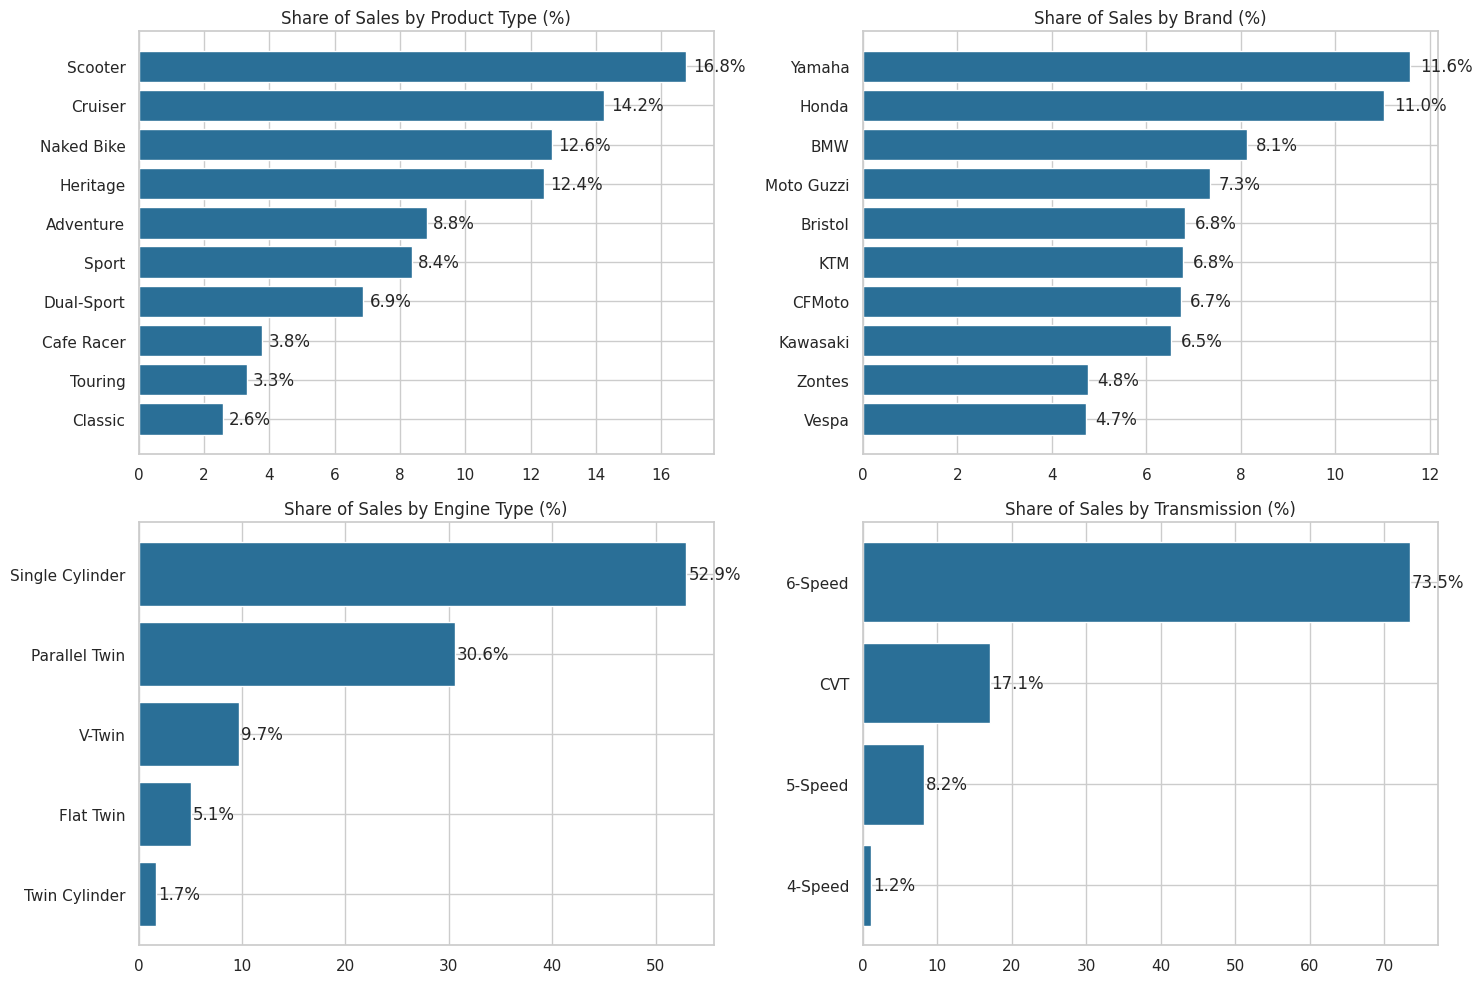

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for ax, col in zip(axes.flat, ["Product Type", "Brand", "Engine Type", "Transmission"]):
    g = attr_summary(col).head(10).iloc[::-1]
    ax.barh(g.index, g["Sales %"], color="#2a6f97")
    for y, v in enumerate(g["Sales %"]): ax.text(v + .2, y, f"{v:.1f}%", va="center")
    ax.set_title(f"Share of Sales by {col} (%)")
plt.tight_layout(); plt.show()

### Interpretation – product attributes
- **Scooters** are the largest category (**16.8% of sales**, 22.6% of transactions) because 12 models share the volume (₱62 million per model).
- **Cruisers (14.2%)** and **Heritage bikes (12.4%)** earn a large share from very few models: 4 cruisers and just 2 heritage models (**₱277 million per model, the highest**). Naked bikes follow with 12.6%.
- **Brands:** Yamaha (11.6%) and Honda (11.0%) lead thanks to many models; BMW (8.1%, 2 models) and Moto Guzzi (7.3%, a single model) punch above their weight.
- **Engine type:** single-cylinder bikes account for 74.4% of transactions but only **52.9%** of sales, while parallel twins make **30.6%** of sales from 18.2% of transactions – higher-priced bikes carry more revenue per sale.
- **Transmission and cooling:** 6-speed models bring in **73.5%** of sales (CVT 17.1%), and liquid-cooled models **71.0%**.

# **8. RELATIONSHIPS BETWEEN NUMERICAL VARIABLES**

                          Unit Price (PHP)  Quantity  Total Sales (PHP)  \
Unit Price (PHP)                      1.00     -0.03               0.57   
Quantity                             -0.03      1.00               0.68   
Total Sales (PHP)                     0.57      0.68               1.00   
Engine Displacement (cc)              0.93     -0.01               0.53   

                          Engine Displacement (cc)  
Unit Price (PHP)                              0.93  
Quantity                                     -0.01  
Total Sales (PHP)                             0.53  
Engine Displacement (cc)                      1.00  
Quantity vs Total Sales (PHP): r = 0.68 (p = 3.1e-133)
Unit Price (PHP) vs Total Sales (PHP): r = 0.57 (p = 8.8e-87)
Unit Price (PHP) vs Quantity: r = -0.03 (p = 4.1e-01)


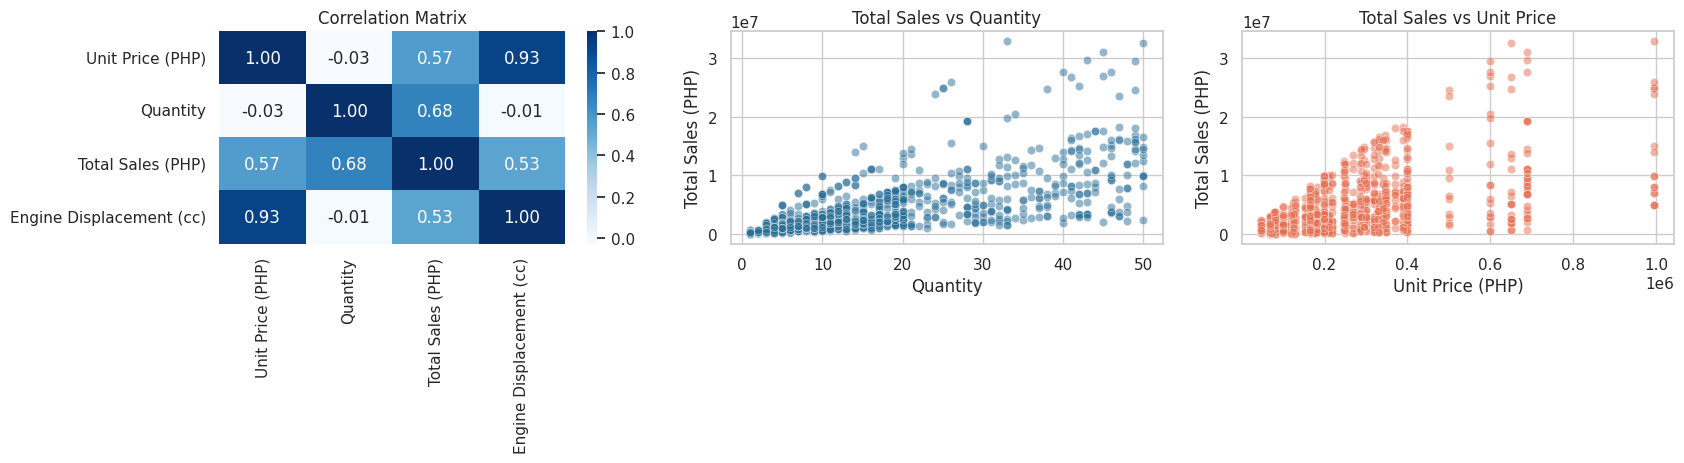

In [21]:
rel_cols = [PRICE, QTY, TOTAL, "Engine Displacement (cc)"]
corr = df[rel_cols].corr()
display(corr.round(2)) if "display" in globals() else print(corr.round(2))
for a, b in [(QTY, TOTAL), (PRICE, TOTAL), (PRICE, QTY)]:
    r, p = stats.pearsonr(df[a], df[b]); print(f"{a} vs {b}: r = {r:.2f} (p = {p:.1e})")

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", ax=axes[0]); axes[0].set_title("Correlation Matrix")
sns.scatterplot(data=df, x=QTY, y=TOTAL, alpha=.5, ax=axes[1], color="#2a6f97"); axes[1].set_title("Total Sales vs Quantity")
sns.scatterplot(data=df, x=PRICE, y=TOTAL, alpha=.5, ax=axes[2], color="#e76f51"); axes[2].set_title("Total Sales vs Unit Price")
plt.tight_layout(); plt.show()

### Interpretation – relationships
- **Total sales** is driven by both quantity (**r = 0.68**) and unit price (**r = 0.57**).
- **Quantity and unit price are essentially unrelated (r = −0.03)**: buyers do not purchase noticeably fewer units of expensive models, which is why premium bikes dominate revenue.
- Unit price is closely tied to engine displacement (**r = 0.93**), and sales per transaction is moderately related to displacement (r = 0.53).
- Correlation shows association, not cause.

# **9. LARGE TRANSACTIONS (OUTLIERS)**

In [22]:
q1, q3 = df[TOTAL].quantile([.25, .75]); fence = q3 + 1.5 * (q3 - q1)
big = df[df[TOTAL] > fence]
print(f"IQR upper fence: ₱{fence:,.0f}")
print(f"Transactions above the fence: {len(big)} ({len(big)/len(df)*100:.1f}% of transactions) = {big[TOTAL].sum()/df[TOTAL].sum()*100:.1f}% of total sales")
print(f"Top 5 transactions = {df.nlargest(5, TOTAL)[TOTAL].sum()/df[TOTAL].sum()*100:.1f}% of total sales\n")
print(df.nlargest(5, TOTAL)[["Date", "Client Type", "Product Name", QTY, TOTAL]].to_string(index=False))
print("\nProducts most often in large transactions:")
print(big["Product Name"].value_counts().head(5).to_string())

IQR upper fence: ₱13,237,500
Transactions above the fence: 65 (6.5% of transactions) = 27.3% of total sales
Top 5 transactions = 3.5% of total sales

      Date Client Type        Product Name  Quantity  Total Sales (PHP)
2025-07-30      Retail         BMW R nineT        33      32,835,000.00
2025-08-25      Retail    Honda Rebel 1100        50      32,500,000.00
2025-08-01      Retail Moto Guzzi V7 Stone        45      31,005,000.00
2025-06-14      Retail Moto Guzzi V7 Stone        43      29,627,000.00
2025-06-22      Retail        KTM 790 Duke        49      29,351,000.00

Products most often in large transactions:
Product Name
Moto Guzzi V7 Stone    8
KTM 790 Duke           7
BMW R nineT            7
Bristol Bobber 650     5
Kawasaki Z400          5


### Interpretation – large transactions
- **65 transactions (6.5%)** exceed the IQR upper fence of about ₱13.2 million and together generate **27.3% of total sales**. They are valid bulk sales of premium models (the five largest, ₱29–33 million each, are mostly retail purchases of 33–50 units), so they were **kept** in the data.
- No single sale is dominant: the top five transactions account for only 3.5% of total sales.

# **10. SUMMARY OF KEY FINDINGS**
1. **₱4.46 billion** in sales from **993 transactions** and **17,598 units** between 1 June and 31 August 2025.
2. Sale values are **right-skewed** (mean ₱4.49 million vs median ₱2.80 million); 6.5% of transactions produce 27.3% of sales.
3. **Retail (53.5%)** edges out wholesale (45.7%) in revenue, but units per transaction are about the same for both.
4. Payment is evenly split between **credit card (35.2%)**, **transfer** and **cash** (about 32% each).
5. Monthly sales **fell about 5%** from June to August, driven by fewer transactions; Thursdays and Mondays are the strongest days.
6. **Premium models drive revenue**: Moto Guzzi V7 Stone, Bristol Bobber 650, BMW R nineT and KTM 790 Duke lead; heritage and cruiser types earn the most per model, while scooters lead overall because of the number of models.
7. Revenue depends on both volume and price, and **quantity does not fall as price rises** (r ≈ −0.03).
8. Records with an unknown client type or payment method are about 1% of the data and do not change the conclusions.